In [1]:
import pandas as pd
import numpy as np
from FaceQuant import FaceQuantVec
import os
from tqdm import tqdm

## Load data

In [16]:
import os

csv_files = []

for root, dirs, files in os.walk('C2shortvideosDLCanalyzed/'):
    for f in files:
        if f.endswith('.csv') and not 'Resnet50' in f:
            csv_files.append(os.path.join(root, f))



In [42]:
all_results = []

ill_dict = {
    '7C':'ill',
    '10B3':'ill',
    '1A1':'ill',
    '1A11':'ill',
    '10B4':'control',
    '1A4':'control',
    '4B1':'control',
    '4B4':'control',
    }

for csv_file in tqdm(csv_files):
    df = pd.read_csv(csv_file, header=[1, 2])
    df.columns.names = ["scorer", "bodyparts"]
    n = len(df)

    if n > 200:
        fq = FaceQuantVec(df)
        quant_df = fq.compute()

        quant_df["group"] = ill_dict[csv_file.split('\\')[1]]

        if '_' not in csv_file.split('\\')[2]:
            phase = 'pre'
        else:
            phase = csv_file.split('\\')[2].split('_')[1]

        quant_df["phase"] = phase 

        if "Airpuff" in csv_file:
            quant_df["stimuli"] = ["neutral"] * 200 + ["airpuf"] * (n - 200)
        elif "quinine" in csv_file:
            quant_df["stimuli"] = ["neutral"] * 200 + ["quinine"] * (n - 200)
        elif "Sucrose" in csv_file:
            quant_df["stimuli"] = ["neutral"] * 200 + ["sucrose"] * (n - 200)
    
        all_results.append(quant_df)

fq_df = pd.concat(all_results, ignore_index=True)


100%|██████████| 205/205 [00:05<00:00, 39.43it/s]


In [45]:
from scipy.stats import zscore

quant_cols = [
    "eye_opening",
    "ear_opening",
    "ear_position",
    "snout_position",
    "mouth_position",
    "face_inclination"
]

fq_df[quant_cols] = fq_df[quant_cols].apply(zscore)
import numpy as np

mean_df = fq_df.groupby("stimuli")[quant_cols].mean()
sem_df  = fq_df.groupby("stimuli")[quant_cols].sem()



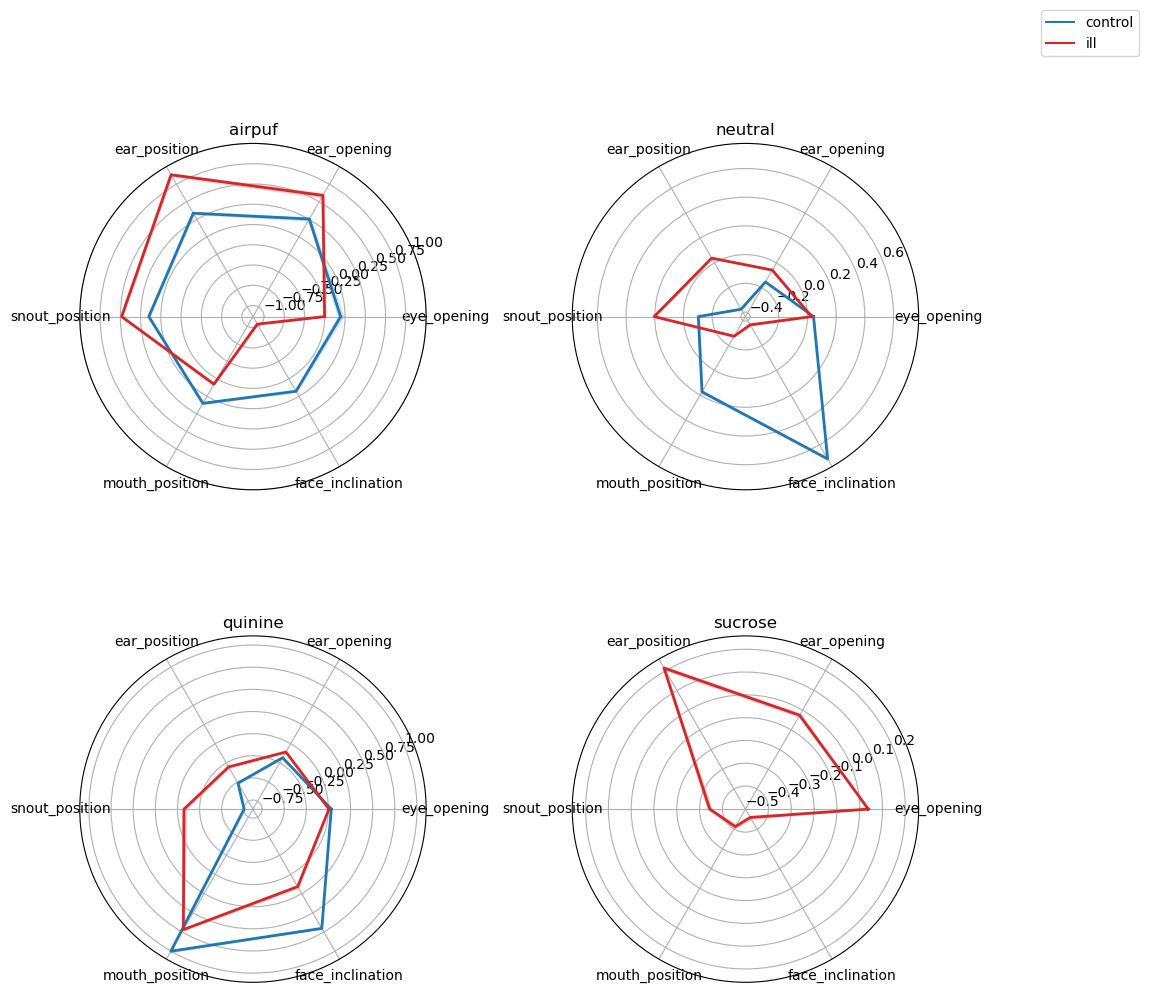

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import math

labels = quant_cols
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

stimuli = sorted(fq_df["stimuli"].unique())
groups = sorted(fq_df["group"].unique())

# Explicit colors per group
group_colors = {
    "ill": "tab:red",
    "control": "tab:blue",
}

cols = 2
rows = math.ceil(len(stimuli) / cols)

fig, axes = plt.subplots(
    rows, cols,
    figsize=(cols * 5, rows * 5),
    subplot_kw=dict(polar=True)
)

axes = axes.flatten()

for ax, stim in zip(axes, stimuli):

    stim_df = fq_df[fq_df["stimuli"] == stim]

    stim_mean = stim_df.groupby("group")[quant_cols].mean()
    stim_sem  = stim_df.groupby("group")[quant_cols].sem()

    for group in groups:
        if group not in stim_mean.index:
            continue

        values = stim_mean.loc[group].tolist()
        values += values[:1]

        sem = stim_sem.loc[group].tolist()
        sem += sem[:1]

        lower = np.array(values) - np.array(sem)
        upper = np.array(values) + np.array(sem)

        color = group_colors.get(group, "gray")

        ax.plot(angles, values, linewidth=2, label=group, color=color)
        ax.fill_between(angles, lower, upper, alpha=0.15, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title(stim)

# Hide unused axes
for ax in axes[len(stimuli):]:
    ax.set_visible(False)

# Global legend with correct colors
handles = []
labels_legend = []

for group in groups:
    color = group_colors.get(group, "gray")
    h, = axes[0].plot([], [], label=group, color=color)
    handles.append(h)
    labels_legend.append(group)

fig.legend(handles, labels_legend, loc="upper right", bbox_to_anchor=(1.15, 1.05))

plt.tight_layout()
plt.show()
